# SqueezeNet Training - Separated Experiments
Each preprocessing version runs in a separate cell to avoid crashes:
- **Experiment 1**: Raw
- **Experiment 2**: Unified  
- **Experiment 3**: Customized

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os, json, gc, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm

# SETUP
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = os.path.join("..", "data")
MODEL_DIR = "."
VIZ_DIR = os.path.join(MODEL_DIR, "visualizations", "squeezenet")
JSON_PATH = os.path.join(DATA_DIR, "dataset_split.json")
CATEGORIES = ['Can', 'Paper', 'Plastic Bag', 'Plastic Bottle']

# Create visualization directory
os.makedirs(VIZ_DIR, exist_ok=True)

print(f"Using device: {DEVICE}")
print(f"Visualization directory: {VIZ_DIR}")

# Load dataset split once
with open(JSON_PATH, 'r') as f: 
    split = json.load(f)
    
print(f"Train samples: {len(split['train'])}")
print(f"Test samples: {len(split['test'])}")

Using device: cuda
Visualization directory: .\visualizations\squeezenet
Train samples: 6319
Test samples: 1358


In [3]:
class WasteJSONDataset(Dataset):
    def __init__(self, root_dir, file_list, transform=None):
        self.root_dir, self.file_list, self.transform = root_dir, file_list, transform
        self.class_to_idx = {cat: i for i, cat in enumerate(CATEGORIES)}
        
    def __len__(self): return len(self.file_list)
        
    def __getitem__(self, idx):
        rel_path = self.file_list[idx]
        path = os.path.join(self.root_dir, rel_path)
        try:
            img = Image.open(path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), (0, 0, 0))
        label = self.class_to_idx[rel_path.split('/')[0]]
        if self.transform: img = self.transform(img)
        return img, label

def train_model_with_history(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for imgs, lbls in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == lbls).sum().item()
            train_total += lbls.size(0)
            
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == lbls).sum().item()
                val_total += lbls.size(0)

        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_correct / train_total)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_correct / val_total)
        print(f"Epoch {epoch+1}: Val Acc: {history['val_acc'][-1]:.4f}")
    return model, history

In [4]:
def count_parameters(model):
    """Bonus: Count model parameters for SqueezeNet comparison"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def plot_metrics(history, y_true, y_pred, version):
    # 1. Learning Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history['train_loss'], label='Train Loss'); ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss - {version.upper()}'); ax1.legend()
    ax2.plot(history['train_acc'], label='Train Acc'); ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'Accuracy - {version.upper()}'); ax2.legend()
    plt.savefig(os.path.join(VIZ_DIR, f"curves_{version}.png"))
    plt.show()

    # 2. Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
    plt.title(f'Confusion Matrix - {version.upper()}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.savefig(os.path.join(VIZ_DIR, f"cm_{version}.png"))
    plt.show()

def run_squeezenet_experiment_with_viz(version, root_path):
    print(f"\n🚀 SqueezeNet Experiment: {version.upper()}")
    if not os.path.exists(root_path): return None
    
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                                   transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    train_ds = WasteJSONDataset(root_path, split['train'], transform)
    test_ds = WasteJSONDataset(root_path, split['test'], transform)
    
    # num_workers=0 to prevent 'fake stuck' on Windows
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
    
    # Initialize SqueezeNet 1.1
    model = models.squeezenet1_1(weights='IMAGENET1K_V1')
    model.num_classes = 4
    model.classifier[1] = nn.Conv2d(512, 4, kernel_size=(1,1))
    model = model.to(DEVICE)
    
    params = count_parameters(model)
    print(f"📦 Model Parameters: {params:,}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    
    trained_model, history = train_model_with_history(model, train_loader, val_loader, criterion, optimizer)
    
    # Evaluation
    all_preds, all_labels = [], []
    trained_model.eval()
    with torch.no_grad():
        for imgs, lbls in val_loader:
            outputs = trained_model(imgs.to(DEVICE))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
            
    plot_metrics(history, all_labels, all_preds, version)
    
    return {
        'Model': 'SqueezeNet', 'Preprocessing': version, 'Params': params,
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'Recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'F1-score': f1_score(all_labels, all_preds, average='macro', zero_division=0)
    }


🚀 SqueezeNet Experiment: RAW
📦 Model Parameters: 724,548


Epoch 1/5 [Val]: 100%|██████████| 43/43 [00:14<00:00,  2.94it/s]


Epoch 1: Val Acc: 0.9161


Epoch 2/5 [Val]: 100%|██████████| 43/43 [00:15<00:00,  2.79it/s]


Epoch 2: Val Acc: 0.9256


...

Epoch 3: Val Acc: 0.9308


Epoch 4/5 [Val]: 100%|██████████| 43/43 [00:15<00:00,  2.71it/s]


Epoch 4: Val Acc: 0.9440


Epoch 5/5 [Val]: 100%|██████████| 43/43 [00:08<00:00,  4.85it/s]


Epoch 5: Val Acc: 0.9507


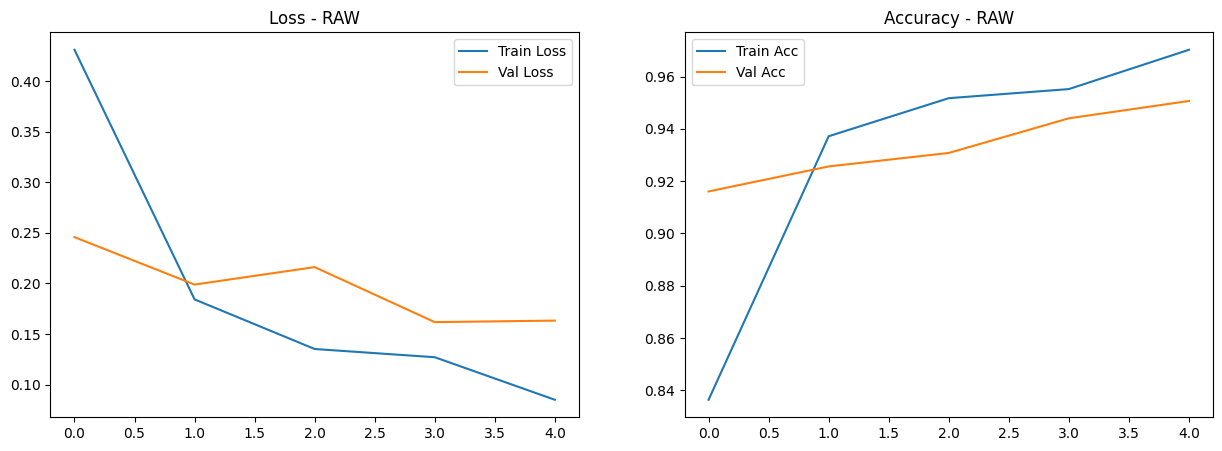

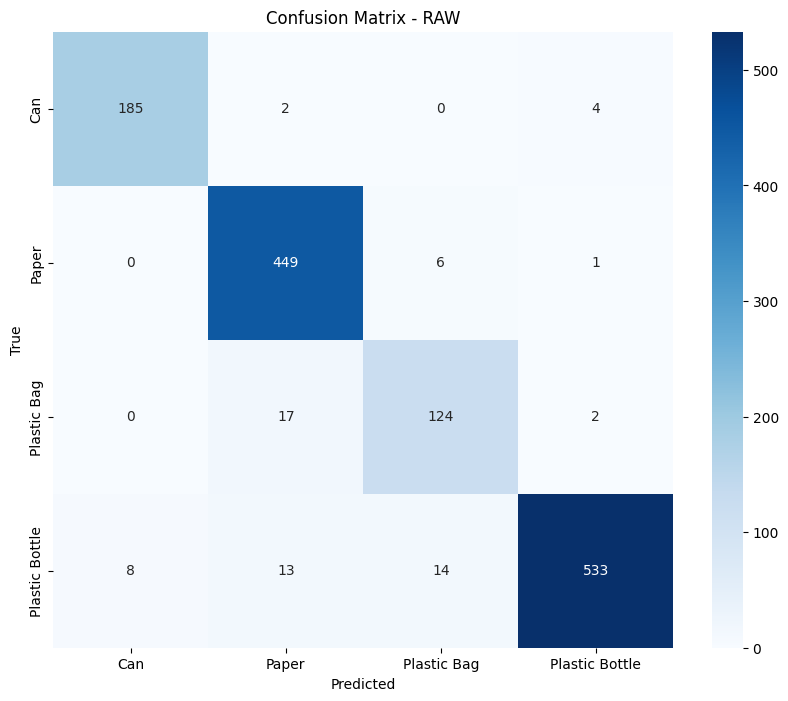

In [5]:
# 🔥 EXPERIMENT 1: RAW
torch.cuda.empty_cache(); gc.collect()
result_raw = run_squeezenet_experiment_with_viz('raw', os.path.join(DATA_DIR, "Cropped"))


🚀 SqueezeNet Experiment: UNIFIED
📦 Model Parameters: 724,548


Epoch 1/5 [Val]: 100%|██████████| 43/43 [00:09<00:00,  4.57it/s]


Epoch 1: Val Acc: 0.7629


Epoch 2/5 [Val]: 100%|██████████| 43/43 [00:15<00:00,  2.76it/s]


Epoch 2: Val Acc: 0.8108


...

Epoch 3: Val Acc: 0.8328


Epoch 4/5 [Val]: 100%|██████████| 43/43 [00:09<00:00,  4.57it/s]


Epoch 4: Val Acc: 0.8049


Epoch 5/5 [Val]: 100%|██████████| 43/43 [00:09<00:00,  4.58it/s]


Epoch 5: Val Acc: 0.8601


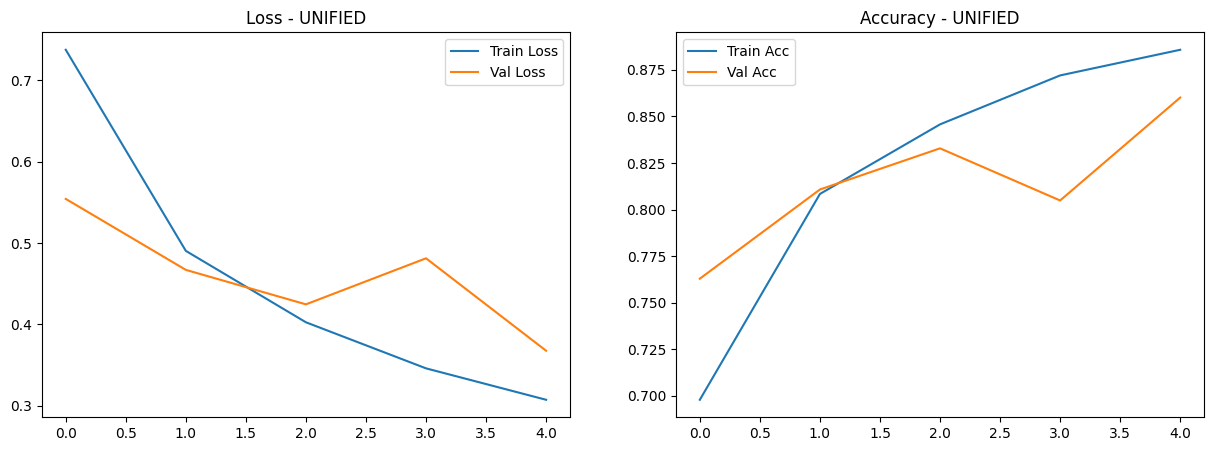

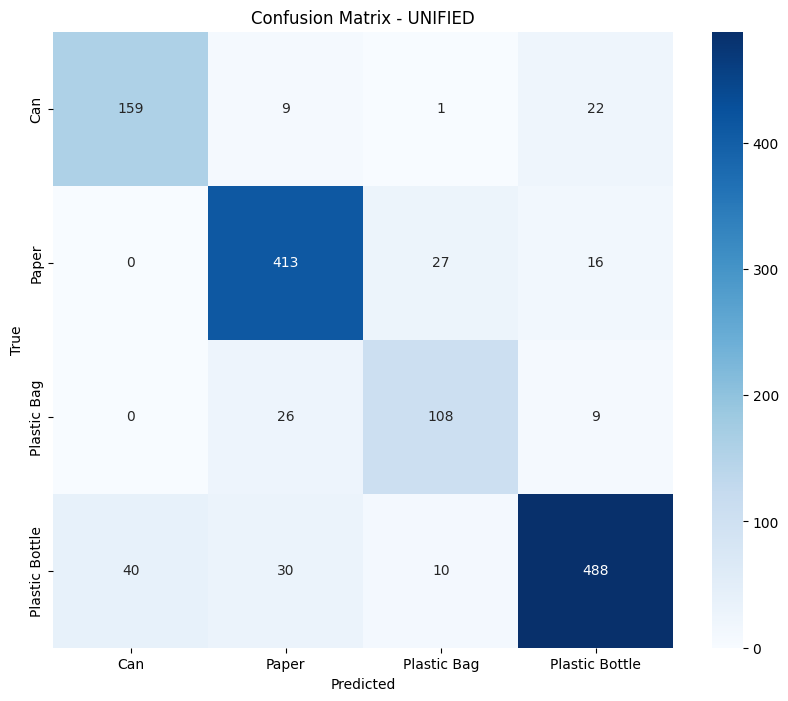

In [6]:
# 🔥 EXPERIMENT 2: UNIFIED
torch.cuda.empty_cache(); gc.collect()
result_unified = run_squeezenet_experiment_with_viz('unified', os.path.join(DATA_DIR, "processed_unified"))


🚀 SqueezeNet Experiment: CUSTOMIZED
📦 Model Parameters: 724,548


Epoch 1/5 [Val]: 100%|██████████| 43/43 [00:14<00:00,  2.95it/s]


Epoch 1: Val Acc: 0.9367


Epoch 2/5 [Val]: 100%|██████████| 43/43 [00:18<00:00,  2.38it/s]


Epoch 2: Val Acc: 0.9470


...

Epoch 3: Val Acc: 0.9389


Epoch 4/5 [Val]: 100%|██████████| 43/43 [00:09<00:00,  4.56it/s]


Epoch 4: Val Acc: 0.9588


Epoch 5/5 [Val]: 100%|██████████| 43/43 [00:08<00:00,  5.22it/s]


Epoch 5: Val Acc: 0.9669


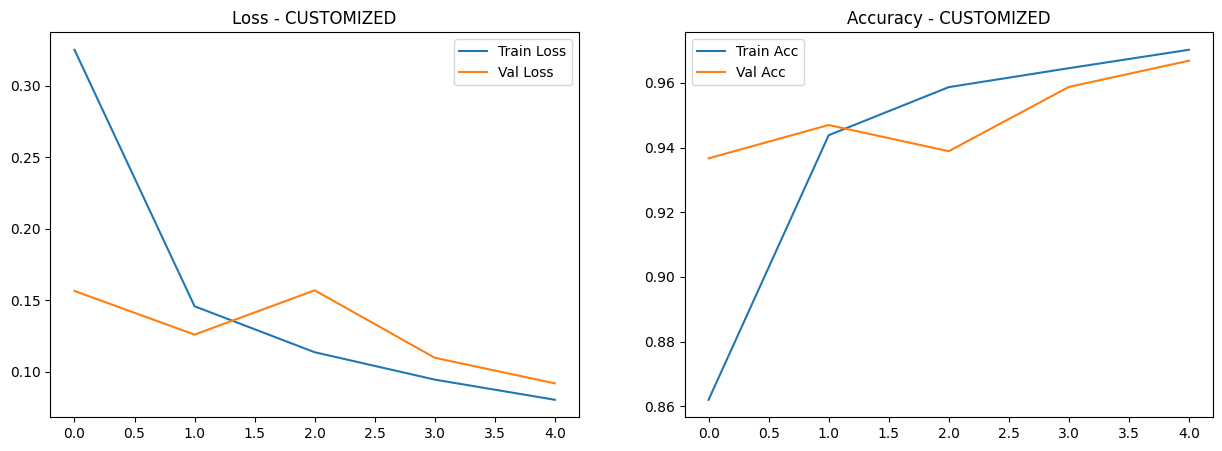

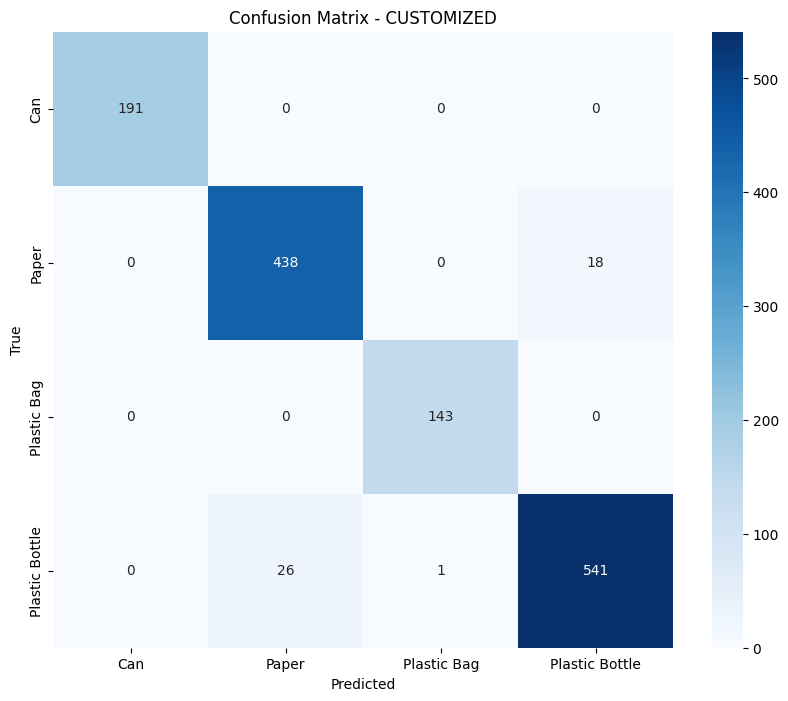

In [7]:
# 🔥 EXPERIMENT 3: CUSTOMIZED
torch.cuda.empty_cache(); gc.collect()
result_customized = run_squeezenet_experiment_with_viz('customized', os.path.join(DATA_DIR, "processed_customized"))


📊 FINAL SQUEEZENET SUMMARY:
     Model Preprocessing  Params  Accuracy  Precision   Recall  F1-score
SqueezeNet           raw  724548  0.950663   0.935042 0.939687  0.937031
SqueezeNet       unified  724548  0.860088   0.828722 0.838141  0.833004
SqueezeNet    customized  724548  0.966863   0.976205 0.978248  0.977190


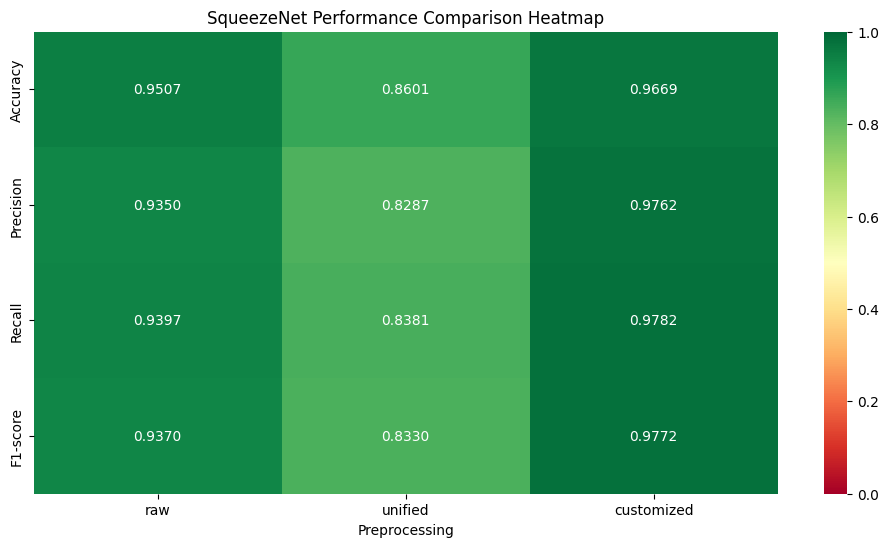


🏁 SqueezeNet experiments with full visualization completed!


In [8]:
all_results = [r for r in [result_raw, result_unified, result_customized] if r is not None]

if all_results:
    df_results = pd.DataFrame(all_results)
    df_results.to_csv(os.path.join(DATA_DIR, "squeezenet_all_results.csv"), index=False)
    
    print(f"\n📊 FINAL SQUEEZENET SUMMARY:\n{'='*60}")
    print(df_results.to_string(index=False))
    
    # Metrics comparison heatmap
    plt.figure(figsize=(12, 6))
    viz_df = df_results[['Preprocessing', 'Accuracy', 'Precision', 'Recall', 'F1-score']].set_index('Preprocessing')
    sns.heatmap(viz_df.T, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=1)
    plt.title('SqueezeNet Performance Comparison Heatmap')
    plt.savefig(os.path.join(VIZ_DIR, "comparison_heatmap.png"))
    plt.show()

print("\n🏁 SqueezeNet experiments with full visualization completed!")